In [3]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ▶ 경로 설정 (※ Colab을 활성화시켰다면 보통 Colab Notebooks 폴더가 자동 생성)
import os
os.chdir("/content/drive/MyDrive/AX/data")
os.getcwd()

import pandas as pd
df = pd.read_csv('top_insta_influencers_data.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rank               200 non-null    int64 
 1   channel_info       200 non-null    object
 2   influence_score    200 non-null    int64 
 3   posts              200 non-null    object
 4   followers          200 non-null    object
 5   avg_likes          200 non-null    object
 6   60_day_eng_rate    200 non-null    object
 7   new_post_avg_like  200 non-null    object
 8   total_likes        200 non-null    object
 9   country            138 non-null    object
dtypes: int64(2), object(8)
memory usage: 15.8+ KB


In [7]:
df.describe()

,rank,influence_score
count,200.000000,200.000000
mean,100.500000,81.820000
std,57.879185,8.878159
min,1.000000,22.000000
25%,50.750000,80.000000
50%,100.500000,84.000000
75%,150.250000,86.000000
max,200.000000,93.000000


In [8]:
df.shape

(200, 10)

In [10]:
print(df.isnull().sum())

#결측치 어디에 얼마나 있는지 알아보기

rank                  0
channel_info          0
influence_score       0
posts                 0
followers             0
avg_likes             0
60_day_eng_rate       0
new_post_avg_like     0
total_likes           0
country              62
dtype: int64


In [11]:
df['country'] = df['country'].fillna('None')

print(df.isnull().sum())

#country는 굳이 필요없으니까 그냥 빈 값을 None으로 채우기

rank                 0
channel_info         0
influence_score      0
posts                0
followers            0
avg_likes            0
60_day_eng_rate      0
new_post_avg_like    0
total_likes          0
country              0
dtype: int64


In [12]:
import pandas as pd
import numpy as np

def convert_to_number(value):
    """기존에 만든 숫자 변환 함수"""
    if pd.isna(value) or str(value).lower().strip() in ["", "-", "none", "null", "nan"]:
        return None
    if isinstance(value, (int, float)):
        return float(value)

    val_str = str(value).lower().replace(',', '').strip()
    try:
        if 'k' in val_str:
            return float(val_str.replace('k', '')) * 1_000
        elif 'm' in val_str:
            return float(val_str.replace('m', '')) * 1_000_000
        elif 'b' in val_str:
            return float(val_str.replace('b', '')) * 1_000_000_000
        else:
            return float(val_str)
    except ValueError:
        return None

def preprocess_columns(df, target_columns):
    """
    for문을 사용하여 지정된 여러 컬럼에 변환 함수를 적용합니다.
    - df: 대상 데이터프레임
    - target_columns: 변환할 컬럼명 리스트 (예: ['followers', 'posts'])
    """
    # 원본 데이터를 보존하기 위해 복사본을 생성합니다.
    df_clean = df.copy()

    for col in target_columns:
        if col in df_clean.columns:
            print(f"[{col}] 컬럼 변환 중...")
            df_clean[col] = df_clean[col].apply(convert_to_number)
        else:
            print(f"경고: [{col}] 컬럼을 찾을 수 없습니다.")

    return df_clean

# --- 실제 적용 예시 ---
df = pd.read_csv('top_insta_influencers_data.csv')

# 변환하고 싶은 숫자형 컬럼들만 리스트로 만듭니다.
# channel_info는 문자열이어야 하므로 제외합니다.
cols_to_fix = ['posts', 'followers', 'avg_likes', 'new_post_avg_like', 'total_likes']

# 함수 실행
df_final = preprocess_columns(df, cols_to_fix)

print("\n--- 최종 데이터 타입 확인 ---")
print(df_final.dtypes)

[posts] 컬럼 변환 중...
[followers] 컬럼 변환 중...
[avg_likes] 컬럼 변환 중...
[new_post_avg_like] 컬럼 변환 중...
[total_likes] 컬럼 변환 중...

--- 최종 데이터 타입 확인 ---
rank                   int64
channel_info          object
influence_score        int64
posts                float64
followers            float64
avg_likes            float64
60_day_eng_rate       object
new_post_avg_like    float64
total_likes          float64
country               object
dtype: object


In [13]:
import pandas as pd
import numpy as np

def convert_percent_to_float(value):
    """
    '1.39%' 형태의 문자열을 0.0139 형태의 숫자(float)로 변환합니다.
    - 빈 값, '-', 'none' 등은 None으로 반환합니다.
    """
    # 1. 결측치 및 예외 문자열 처리
    if pd.isna(value) or str(value).lower().strip() in ["", "-", "none", "null", "nan"]:
        return None

    # 2. 문자열 정규화
    val_str = str(value).strip()

    try:
        # 3. % 기호가 있다면 제거하고 숫자로 변환 후 100으로 나눔
        if '%' in val_str:
            return float(val_str.replace('%', '')) / 100
        else:
            # %가 없는 일반 숫자인 경우에도 대비 (예: 1.39 -> 0.0139)
            return float(val_str) / 100

    except ValueError:
        # 숫자로 바꿀 수 없는 문자열인 경우
        return None

# --- 테스트 코드 ---
test_cases = ["1.39%", "0.5%", "15%", "-", "none", ""]
print("--- 퍼센트 변환 테스트 ---")
for case in test_cases:
    print(f"입력: {str(case):<7} -> 결과: {convert_percent_to_float(case)}")

--- 퍼센트 변환 테스트 ---
입력: 1.39%   -> 결과: 0.0139
입력: 0.5%    -> 결과: 0.005
입력: 15%     -> 결과: 0.15
입력: -       -> 결과: None
입력: none    -> 결과: None
입력:         -> 결과: None


In [14]:
# 데이터 로드
df = pd.read_csv('top_insta_influencers_data.csv')

# 퍼센트 변환이 필요한 컬럼 리스트
percent_cols = ['60_day_eng_rate']

# for문을 이용한 일괄 적용
for col in percent_cols:
    if col in df.columns:
        df[col] = df[col].apply(convert_percent_to_float)

# 결과 확인
print("\n--- 변환 후 데이터 확인 ---")
print(df[['channel_info', '60_day_eng_rate']].head())


--- 변환 후 데이터 확인 ---
  channel_info  60_day_eng_rate
0    cristiano           0.0139
1  kyliejenner           0.0162
2     leomessi           0.0124
3  selenagomez           0.0097
4      therock           0.0020


In [22]:
import pandas as pd
import numpy as np

# 1. 일반 숫자 단위 변환 함수 (k, m, b)
def convert_to_number(value):
    if pd.isna(value) or str(value).lower().strip() in ["", "-", "none", "null", "nan"]:
        return None
    if isinstance(value, (int, float)):
        return float(value)

    val_str = str(value).lower().replace(',', '').strip()
    try:
        if 'k' in val_str:
            return float(val_str.replace('k', '')) * 1_000
        elif 'm' in val_str:
            return float(val_str.replace('m', '')) * 1_000_000
        elif 'b' in val_str:
            return float(val_str.replace('b', '')) * 1_000_000_000
        else:
            return float(val_str)
    except ValueError:
        return None

# 2. 퍼센트 전용 변환 함수 (%)
def convert_percent_to_float(value):
    if pd.isna(value) or str(value).lower().strip() in ["", "-", "none", "null", "nan"]:
        return None

    val_str = str(value).strip()
    try:
        if '%' in val_str:
            return float(val_str.replace('%', '')) / 100
        else:
            return float(val_str) / 100
    except ValueError:
        return None

# --- 실제 데이터 처리 과정 ---

# 3. 데이터 로드
df = pd.read_csv('top_insta_influencers_data.csv')

# 4. 일반 숫자 컬럼들 일괄 변환 (for문 사용)
num_cols = ['posts', 'followers', 'avg_likes', 'new_post_avg_like', 'total_likes']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].apply(convert_to_number)

# 5. 퍼센트 컬럼 일괄 변환 (for문 사용)
percent_cols = ['60_day_eng_rate']
for col in percent_cols:
    if col in df.columns:
        df[col] = df[col].apply(convert_percent_to_float)

# 6. 최종 결과 확인
print("--- 모든 전처리 완료 후 타입 확인 ---")
print(df.dtypes)
print("\n--- 전처리 데이터 상위 5개 확인 ---")
print(df.head())

# 7. (선택사항) 전처리된 결과를 새 파일로 저장하고 싶다면:
# df.to_csv('cleaned_insta_data.csv', index=False)

--- 모든 전처리 완료 후 타입 확인 ---
rank                   int64
channel_info          object
influence_score        int64
posts                float64
followers            float64
avg_likes            float64
60_day_eng_rate      float64
new_post_avg_like    float64
total_likes          float64
country               object
dtype: object

--- 전처리 데이터 상위 5개 확인 ---
   rank channel_info  influence_score   posts    followers  avg_likes  \
0     1    cristiano               92  3300.0  475800000.0  8700000.0   
1     2  kyliejenner               91  6900.0  366200000.0  8300000.0   
2     3     leomessi               90   890.0  357300000.0  6800000.0   
3     4  selenagomez               93  1800.0  342700000.0  6200000.0   
4     5      therock               91  6800.0  334100000.0  1900000.0   

   60_day_eng_rate  new_post_avg_like   total_likes        country  
0           0.0139          6500000.0  2.900000e+10          Spain  
1           0.0162          5900000.0  5.740000e+10  United States 

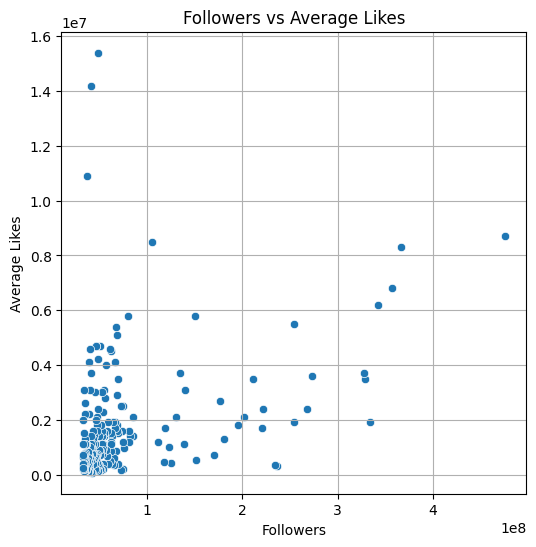

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='followers', y='avg_likes')

plt.title("Followers vs Average Likes")
plt.xlabel("Followers")
plt.ylabel("Average Likes")
plt.grid(True)
plt.show()

In [24]:
corr_followers_likes = df[['followers', 'avg_likes']].corr().iloc[0, 1]
print(round(corr_followers_likes, 3))

0.349


In [25]:
followers_75 = df['followers'].quantile(0.75)
likes_25 = df['avg_likes'].quantile(0.25)

print("팔로워 상위 25% 기준:", followers_75)
print("평균 좋아요 하위 25% 기준:", likes_25)

팔로워 상위 25% 기준: 68900000.0
평균 좋아요 하위 25% 기준: 504400.0


In [26]:
low_engagement_accounts = df[
    (df['followers'] >= followers_75) &
    (df['avg_likes'] <= likes_25)
]

low_engagement_accounts[
    ['rank', 'channel_info', 'followers', 'avg_likes', 'influence_score', 'country']
]

,rank,channel_info,followers,avg_likes,influence_score,country
11,12,natgeo,237000000.0,302200.0,91,United States
12,13,nike,234100000.0,329000.0,90,United States
27,28,theellenshow,125100000.0,420500.0,87,United States
30,31,chrisbrownofficial,118500000.0,463200.0,86,United States
40,41,snoopdogg,75300000.0,203700.0,86,NaN
44,45,victoriassecret,73200000.0,147000.0,88,United States
47,48,nba,70100000.0,370800.0,87,United States


In [ ]:
#↑대부분 기업 계정 (개인 운영 계정이 아닌 경우가 많음)
#influence_score 높다고 해서 좋아요 수 높은 게 아니라는 걸 확인 가능
#즉 influence_score가 유의미하다고 보기 어려울 수 있음

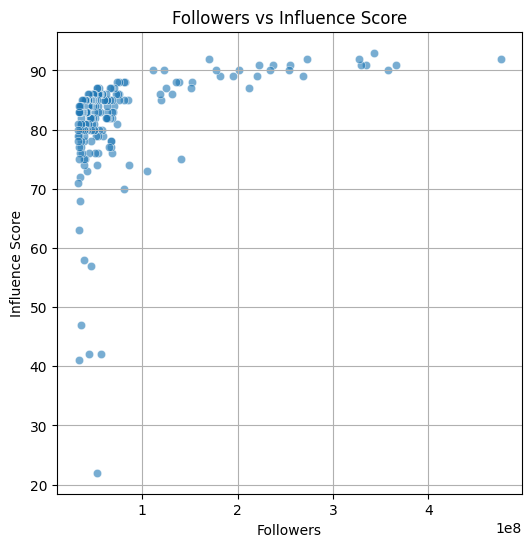

In [27]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x='followers', y='influence_score', alpha=0.6)

plt.title("Followers vs Influence Score")
plt.xlabel("Followers")
plt.ylabel("Influence Score")
plt.grid(True)
plt.show()

In [28]:
corr_followers_score = df[['followers', 'influence_score']].corr().iloc[0, 1]
print(f"상관계수: {corr_followers_score:.3f}")

상관계수: 0.368


In [29]:
followers_75 = df['followers'].quantile(0.75)
followers_score_75 = df['influence_score'].quantile(0.75)

print("팔로워 상위 25% 기준:", followers_75)
print("영향력점수 상위 25% 기준:", followers_score_75)

high_power_accounts = df[
    (df['followers'] >= followers_75) &
    (df['influence_score'] <= followers_score_75)
]

high_power_accounts[
    ['rank', 'channel_info', 'followers', 'avg_likes', 'influence_score', 'country']
]

팔로워 상위 25% 기준: 68900000.0
영향력점수 상위 25% 기준: 86.0


,rank,channel_info,followers,avg_likes,influence_score,country
23,24,iamcardib,140500000.0,3100000.0,75,United States
26,27,kingjames,130900000.0,2100000.0,86,NaN
29,30,champagnepapi,119600000.0,1700000.0,85,Netherlands
30,31,chrisbrownofficial,118500000.0,463200.0,86,United States
32,33,billieeilish,105200000.0,8500000.0,73,NaN
33,34,dualipa,85900000.0,2100000.0,74,United Kingdom
34,35,gal_gadot,85600000.0,1400000.0,85,United States
37,38,priyankachopra,81100000.0,1600000.0,85,United States
38,39,lalalalisa_m,80900000.0,5800000.0,70,NaN
40,41,snoopdogg,75300000.0,203700.0,86,NaN


In [31]:
df['custom_engagement_rate'] = df['avg_likes'] / df['followers']

In [33]:
# 4. 상위 25% 지점(Q3) 계산
# .quantile(0.75)를 사용하면 하위 75% 지점, 즉 상위 25%의 기준값을 구해줍니다.
threshold = df['custom_engagement_rate'].quantile(0.75)

# 5. 상위 25% 데이터 필터링 및 정렬
top_25_df = df[df['custom_engagement_rate'] >= threshold].copy()
top_25_df = top_25_df.sort_values(by='custom_engagement_rate', ascending=False)

# 6. 컬럼명 변경 및 최종 출력 형식 정리
final_result = top_25_df[['rank', 'channel_info', 'followers', 'avg_likes', 'custom_engagement_rate', 'influence_score', 'country']]
final_result.columns = ['순위', '채널명', '팔로워수', '좋아요수', '참여율지표', '영향력점수', '국가']

print(f"참여율 상위 25% 기준값: {threshold:.4f}")
print(final_result.head(10))

참여율 상위 25% 기준값: 0.0302
      순위              채널명        팔로워수        좋아요수     참여율지표  영향력점수  \
140  141              j.m  41900000.0  14200000.0  0.338902     83   
102  103              thv  49300000.0  15400000.0  0.312373     83   
167  168            rkive  37000000.0  10900000.0  0.294595     83   
147  148  jenniferaniston  40700000.0   4600000.0  0.113022     85   
155  156         mahi7781  39100000.0   4100000.0  0.104859     58   
118  119             zayn  46500000.0   4700000.0  0.101075     82   
114  115      harrystyles  46900000.0   4700000.0  0.100213     57   
97    98            adele  50700000.0   4700000.0  0.092702     84   
186  187      blakelively  34600000.0   3100000.0  0.089595     80   
138  139       badbunnypr  42100000.0   3700000.0  0.087886     83   

                국가  
140            NaN  
102            NaN  
167            NaN  
147            NaN  
155            NaN  
118  United States  
114  United States  
97   United States  
186  United State

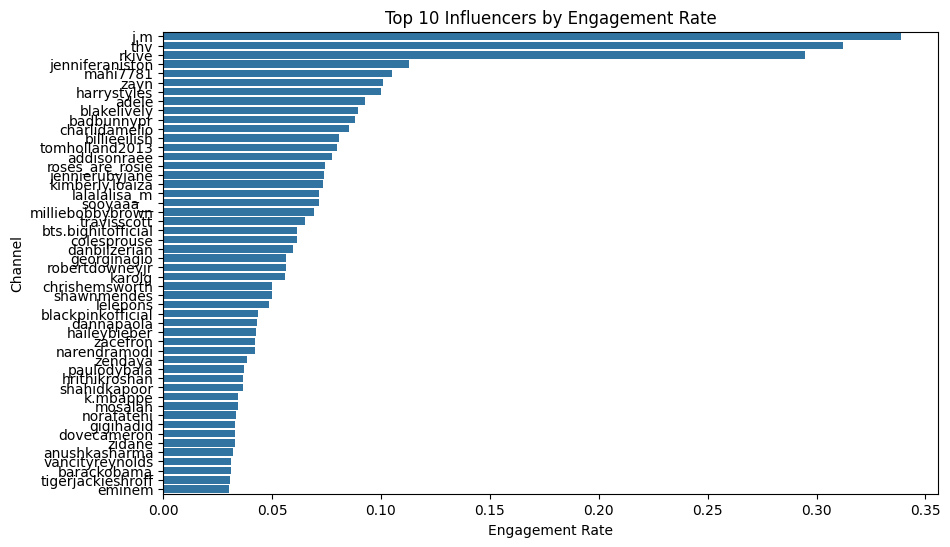

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_25_df,
    x='custom_engagement_rate',
    y='channel_info'
)

plt.title("Top 10 Influencers by Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Channel")
plt.show()

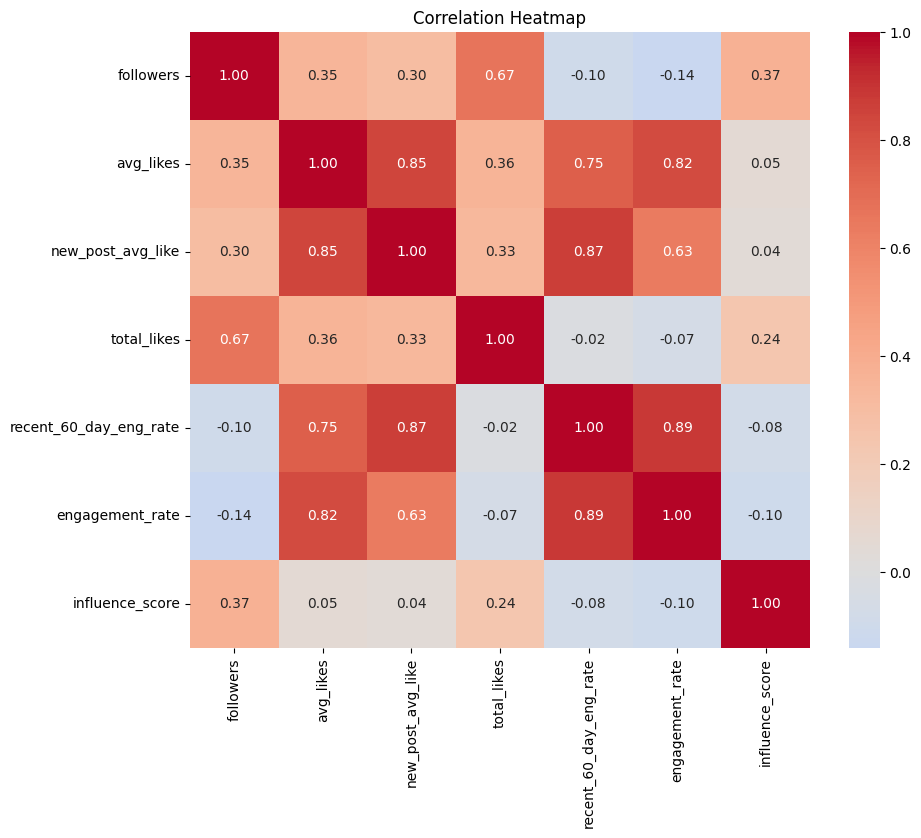

In [37]:
# 1. 컬럼명 정규화 및 데이터 타입 변환
# 원본 파일의 '60_day_eng_rate'를 'recent_60_day_eng_rate'로 새롭게 정의하여 사용합니다.
df['recent_60_day_eng_rate'] = df['60_day_eng_rate'].apply(convert_percent_to_float)
df['engagement_rate'] = df['avg_likes'] / df['followers']

# 2. 분석할 수치형 컬럼 리스트
numeric_cols = [
    'followers',
    'avg_likes',
    'new_post_avg_like',
    'total_likes',
    'recent_60_day_eng_rate',
    'engagement_rate',
    'influence_score'
]

# 3. 상관관계 계산 시 .dropna()를 사용하여 결측치 제거 후 수치형 데이터만 추출
# (매우 중요) 전처리 함수를 거치지 않은 데이터가 섞여있으면 .corr()에서 오류가 납니다.
corr_matrix = df[numeric_cols].apply(pd.to_numeric, errors='coerce').corr()

# 4. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [38]:
import numpy as np

def minmax(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

# 팔로워 수는 값 차이가 매우 크므로 로그 변환 후 점수화
df['followers_log'] = np.log1p(df['followers'])

df['followers_score_0_100'] = minmax(df['followers_log'])
df['engagement_score_0_100'] = minmax(df['engagement_rate'])
df['recent_eng_score_0_100'] = minmax(df['recent_60_day_eng_rate'].fillna(0))
df['influence_score_0_100'] = minmax(df['influence_score'])

df['balanced_influencer_score'] = (
    0.35 * df['influence_score_0_100'] +
    0.25 * df['followers_score_0_100'] +
    0.25 * df['engagement_score_0_100'] +
    0.15 * df['recent_eng_score_0_100']
)

In [41]:
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country,engagement_rate,custom_engagement_rate,recent_60_day_eng_rate,followers_log,followers_score_0_100,engagement_score_0_100,recent_eng_score_0_100,influence_score_0_100,balanced_influencer_score
0,1,cristiano,92,3300.0,475800000.0,8700000.0,0.0139,6500000.0,2.900000e+10,Spain,0.018285,0.018285,0.000139,19.980508,100.000000,5.038070,5.263158,98.591549,61.556034
1,2,kyliejenner,91,6900.0,366200000.0,8300000.0,0.0162,5900000.0,5.740000e+10,United States,0.022665,0.022665,0.000162,19.718690,90.210835,6.335424,6.134040,97.183099,59.070755
2,3,leomessi,90,890.0,357300000.0,6800000.0,0.0124,4400000.0,6.000000e+09,NaN,0.019032,0.019032,0.000124,19.694086,89.290917,5.259212,4.695191,95.774648,57.862937
3,4,selenagomez,93,1800.0,342700000.0,6200000.0,0.0097,3300000.0,1.150000e+10,United States,0.018092,0.018092,0.000097,19.652366,87.731027,4.980798,3.672851,100.000000,58.728884
4,5,therock,91,6800.0,334100000.0,1900000.0,0.0020,665300.0,1.250000e+10,United States,0.005687,0.005687,0.000020,19.626951,86.780777,1.306712,0.757289,97.183099,56.149550


In [42]:
# 'balanced_influencer_score' 기준 내림차순(ascending=False) 정렬
df_sorted = df.sort_values(by='balanced_influencer_score', ascending=False)

# 결과 출력 (상위 20개)
print(df_sorted[['channel_info', 'balanced_influencer_score', 'influence_score', 'followers']].head(20))

        channel_info  balanced_influencer_score  influence_score    followers
140              j.m                  72.359177               83   41900000.0
102              thv                  71.568580               83   49300000.0
0          cristiano                  61.556034               92  475800000.0
1        kyliejenner                  59.070755               91  366200000.0
3        selenagomez                  58.728884               93  342700000.0
2           leomessi                  57.862937               90  357300000.0
6       arianagrande                  57.444628               92  327700000.0
5      kimkardashian                  56.763814               91  329200000.0
4            therock                  56.149550               91  334100000.0
7            beyonce                  55.621913               92  272800000.0
10     kendalljenner                  55.321767               90  254000000.0
9       justinbieber                  53.958993               91

In [43]:
followers_75 = df['followers'].quantile(0.75)
likes_25 = df['avg_likes'].quantile(0.25)
engagement_90 = df['engagement_rate'].quantile(0.90)
followers_50 = df['followers'].quantile(0.50)
score_75 = df['influence_score'].quantile(0.75)

def get_segment(row):
    if (row['followers'] >= followers_75) and (row['avg_likes'] <= likes_25):
        return '팔로워 많음·평균 좋아요 낮음'

    elif row['engagement_rate'] >= engagement_90:
        return '참여율 상위 10%'

    elif (row['followers'] <= followers_50) and (row['influence_score'] >= score_75):
        return '팔로워 중위 이하·영향력 점수 높음'

    else:
        return '일반 계정'

df['insight_segment'] = df.apply(get_segment, axis=1)